In [1]:
from sys import path
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import progressbar
from jupyfun import bin_centers

%matplotlib inline
auto_plot_style()

path.append("../analysis")

from utils import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
folder    = Path("/home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/")
folder_s1 = folder / "s1"
folder_s2 = folder / "s2"

outputfile = folder / "light_tables.h5"
str(outputfile)

'/home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/light_tables.h5'

In [4]:
def empty_s1_map(nbins, sensor_ids):
    xybin = np.arange(nbins)
    zbin, xbin, ybin, sensor_id = map(np.ravel, np.meshgrid(xybin, xybin, xybin, sensor_ids, indexing="ij"))
    return pd.DataFrame(dict(xbin=xbin, ybin=ybin, zbin=zbin, sensor_id=sensor_id, nevt=0, prob=0.0))

def empty_s2_map(nbins, sensor_ids):
    xybin = np.arange(nbins)
    xbin, ybin, sensor_id = map(np.ravel, np.meshgrid(xybin, xybin, sensor_ids, indexing="ij"))
    return pd.DataFrame(dict(xbin=xbin, ybin=ybin, sensor_id=sensor_id, nevt=0, prob=0.0))

def expand_imgs(row, sensor_ids):
    probs = np.concatenate([ row.prob_np.values[0].flatten()
                           , row.prob_fp.values[0].flatten()
                           ])
    probs = dict( nevt = row.nevt.values[0]
                , prob = probs)
    return pd.DataFrame(probs, index=sensor_ids)

# S1

In [5]:
filenames  = sorted(folder_s1.glob("*h5"))

len(filenames)

140

In [6]:
conf       = simconfig(filenames[0])
nphot      = conf.nparticles
zmax       = conf.drift_length # mm
rmax       = conf.el_diam/2 + conf.form_factor * zmax  # mm
nbins      = 100
xybins     = np.linspace(-rmax, rmax, nbins+1)
zbins      = np.linspace(0, zmax, nbins+1) + conf.neck_length
xybinsize  = np.diff(xybins)[0]
zbinsize   = np.diff( zbins)[0]
xycenters  = bin_centers(xybins)
zcenters   = bin_centers( zbins)
sensor_ids = pd.concat([ empty_sensor_df(conf.n_sipm_side, "np")
                       , empty_sensor_df(conf.n_sipm_side, "fp")
                       ]).index.to_series()
meta_s1 = pd.Series(dict( **conf
                        , rmax      = rmax
                        , zmax      = zmax
                        ,  nbins    = nbins
                        , xybins    = xybins
                        ,  zbins    = zbins
                        , xycenters = xycenters
                        , xybinsize = xybinsize
                        ,  zcenters = zcenters
                        ,  zbinsize = zbinsize
                        ), name="meta")

In [7]:
data = []
for filename in progressbar(filenames):
    imgs = imgs_from_file(filename, signal="s1", fp=True)
    imgs.insert(0, "nevt", 1)
    imgs.insert(0, "ybin", np.clip(np.digitize(imgs.y0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "xbin", np.clip(np.digitize(imgs.x0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "zbin", np.clip(np.digitize(imgs.z0,  zbins)-1, 0, nbins-1))
    imgs.reset_index(inplace=True)
    imgs.drop(columns="event x0 y0 r0 z0".split(), inplace=True)
    data.append(imgs)
data_s1 = pd.concat(data, ignore_index=True)

Item 5 of 140 | 60.26 s/item | ETA 136.6 min | Ellapsed 4.0 min

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x78217289e050>>
Traceback (most recent call last):
  File "/home/gonzalo/sw/anaconda3/envs/COLINA/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x78217289e050>>
Traceback (most recent call last):
  File "/home/gonzalo/sw/anaconda3/envs/COLINA/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



In [8]:
data_s1

,zbin,xbin,ybin,nevt,image_np,image_fp
0,8,50,51,1,"[[[4, 4, 3, 5, 5], [5, 6, 7, 5, 2], [4, 13, 12...","[[[3, 1, 1, 0, 2, 2, 7, 5, 3, 2], [3, 3, 4, 3,..."
1,31,53,35,1,"[[[0, 2, 1, 0, 0], [2, 1, 3, 0, 2], [1, 0, 1, ...","[[[3, 1, 5, 3, 3, 6, 5, 7, 5, 1], [4, 1, 2, 2,..."
2,45,46,37,1,"[[[1, 2, 3, 1, 1], [0, 1, 1, 1, 3], [1, 2, 0, ...","[[[5, 6, 3, 4, 5, 3, 8, 2, 7, 2], [2, 4, 4, 3,..."
3,49,45,35,1,"[[[0, 0, 0, 0, 1], [2, 0, 0, 3, 5], [2, 1, 4, ...","[[[9, 2, 1, 3, 3, 8, 3, 5, 2, 3], [3, 8, 3, 6,..."
4,95,29,12,1,"[[[1, 0, 0, 3, 0], [0, 1, 0, 1, 0], [0, 1, 1, ...","[[[1, 1, 2, 2, 1, 3, 1, 0, 0, 0], [0, 2, 4, 1,..."
...,...,...,...,...,...,...
1999995,75,64,59,1,"[[[1, 0, 2, 0, 0], [0, 2, 1, 0, 1], [5, 1, 2, ...","[[[1, 1, 3, 1, 2, 2, 0, 2, 3, 0], [4, 3, 0, 0,..."
1999996,64,34,62,1,"[[[0, 1, 0, 0, 0], [2, 1, 0, 1, 0], [1, 2, 0, ...","[[[1, 2, 2, 1, 1, 5, 0, 6, 3, 4], [4, 4, 4, 1,..."
1999997,68,38,34,1,"[[[1, 0, 1, 2, 0], [1, 1, 0, 3, 2], [1, 2, 1, ...","[[[1, 3, 2, 4, 0, 1, 7, 1, 2, 5], [9, 7, 6, 6,..."
1999998,98,76,40,1,"[[[1, 1, 0, 6, 1], [0, 4, 3, 3, 1], [0, 1, 1, ...","[[[0, 1, 3, 1, 4, 3, 2, 0, 0, 2], [2, 0, 0, 0,..."


In [9]:
data = data_s1

lt = (data.groupby("zbin xbin ybin".split())
          .sum()
          .assign( prob_np = lambda df: df.image_np/df.nevt/nphot
                 , prob_fp = lambda df: df.image_fp/df.nevt/nphot
                 )
          .drop(columns="image_np image_fp".split())
          .groupby(level=(0,1,2))
          .apply(expand_imgs, sensor_ids)
          .reset_index()
     )

lt = (pd.concat([empty_s1_map(nbins, sensor_ids), lt], ignore_index=True)
        .groupby("sensor_id zbin xbin ybin".split())
        .last()
        .reset_index(level=(1,2,3))
     )
lt.insert(3, "y", (lt.ybin * xybinsize) + xycenters.min())
lt.insert(3, "x", (lt.xbin * xybinsize) + xycenters.min())
lt.insert(3, "z", (lt.zbin *  zbinsize) +  zcenters.min())

s1_lt = lt
s1_lt

,zbin,xbin,ybin,z,x,y,nevt,prob
sensor_id,,,,,,,,
0,0,0,0,10.6,-134.64,-134.64,0,0.0
0,0,0,1,10.6,-134.64,-131.92,0,0.0
0,0,0,2,10.6,-134.64,-129.20,0,0.0
0,0,0,3,10.6,-134.64,-126.48,0,0.0
0,0,0,4,10.6,-134.64,-123.76,0,0.0
...,...,...,...,...,...,...,...,...
4024,99,99,95,129.4,134.64,123.76,0,0.0
4024,99,99,96,129.4,134.64,126.48,0,0.0
4024,99,99,97,129.4,134.64,129.20,0,0.0


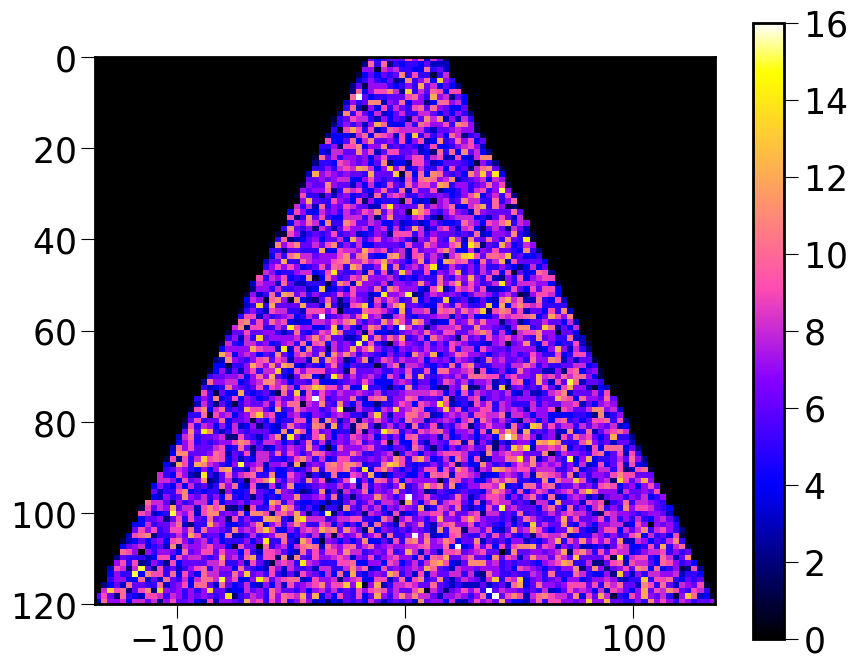

In [16]:
lt0 = lt.loc[2020].loc[lambda df: df.ybin==nbins//2]
img = lt0.nevt.values
plt.imshow( img.reshape(nbins, nbins)
          , origin = "lower"
          , vmin   = 0
          , vmax   = np.percentile(img, 99.9)
          , extent = (-rmax, rmax, 0, zmax)
          , aspect = 2)

plt.gca().invert_yaxis()
plt.colorbar()

# S2

In [4]:
filenames  = sorted(folder_s2.glob("*h5"))
outputfile = folder_s2.parent / "s2.lt"

len(filenames), str(outputfile)

(40, '/home/gonzalo/data/COLINA/mc/pcolina/light_tables/20260311/s2.lt')

In [5]:
conf       = simconfig(filenames[0])
nphot      = conf.nparticles
rmax       = conf.el_diam/2 + 1  # mm
nbins      = 200
xybins     = np.linspace(-rmax, rmax, nbins+1)
xybinsize  = np.diff(xybins)[0]
xycenters  = bin_centers(xybins)
sensor_ids = pd.concat([ empty_sensor_df(conf.n_sipm_side, "np")
                       , empty_sensor_df(conf.n_sipm_side, "fp")
                       ]).index.to_series()
meta = pd.Series(dict( **conf
                     , rmax      = rmax
                     , nbins     = nbins
                     , xybins    = xybins
                     , xycenters = xycenters
                     , xybinsize = xybinsize
                     ), name="meta")

In [9]:
data = []
for filename in progressbar(filenames):
    imgs = imgs_from_file(filename, signal="s2", fp=True)
    imgs.insert(0, "nevt", 1)
    imgs.insert(0, "ybin", np.clip(np.digitize(imgs.y0, xybins)-1, 0, nbins-1))
    imgs.insert(0, "xbin", np.clip(np.digitize(imgs.x0, xybins)-1, 0, nbins-1))
    imgs.reset_index(inplace=True)
    imgs.drop(columns="event x0 y0 z0 r0".split(), inplace=True)
    data.append(imgs)
data = pd.concat(data, ignore_index=True)

Item 40 of 40 | 65.01 s/item | ETA 1.1 min | Ellapsed 42.3 minn


In [10]:
data

,xbin,ybin,nevt,image_np,image_fp
0,181,144,1,"[[[3, 2, 1, 0, 1], [2, 6, 9, 2, 2], [2, 12, 15...","[[[0, 0, 1, 2, 0, 0, 1, 0, 2, 0], [2, 0, 0, 1,..."
1,60,63,1,"[[[21, 24, 17, 22, 7], [23, 34, 46, 14, 11], [...","[[[0, 0, 0, 1, 1, 1, 0, 0, 1, 1], [1, 0, 2, 1,..."
2,137,148,1,"[[[1, 2, 6, 1, 0], [1, 6, 4, 1, 2], [9, 17, 6,...","[[[2, 1, 0, 1, 1, 2, 1, 1, 0, 1], [1, 0, 0, 0,..."
3,33,71,1,"[[[27, 34, 35, 17, 4], [13, 23, 25, 16, 16], [...","[[[0, 1, 0, 0, 1, 1, 2, 1, 3, 2], [3, 1, 1, 0,..."
4,150,27,1,"[[[1, 5, 1, 2, 0], [6, 12, 10, 2, 0], [6, 7, 5...","[[[1, 0, 2, 0, 0, 2, 2, 0, 0, 1], [1, 1, 0, 0,..."
...,...,...,...,...,...
1999995,141,27,1,"[[[6, 12, 5, 5, 0], [14, 12, 8, 6, 1], [30, 21...","[[[3, 1, 1, 1, 0, 0, 0, 0, 2, 1], [1, 0, 0, 0,..."
1999996,58,181,1,"[[[0, 11, 7, 13, 4], [1, 8, 14, 32, 21], [0, 9...","[[[0, 1, 1, 0, 1, 0, 0, 0, 0, 0], [2, 0, 0, 1,..."
1999997,186,92,1,"[[[1, 2, 2, 0, 1], [6, 6, 9, 7, 4], [19, 17, 1...","[[[0, 3, 1, 0, 0, 1, 0, 2, 0, 0], [0, 0, 1, 0,..."
1999998,27,137,1,"[[[9, 16, 22, 29, 3], [7, 17, 22, 27, 14], [4,...","[[[1, 0, 0, 1, 1, 0, 0, 1, 2, 1], [0, 0, 0, 2,..."


In [11]:
def row_to_table(row):
    probs = np.concatenate([ row.prob_np.values[0].flatten()
                           , row.prob_fp.values[0].flatten()
                           ])
    probs = dict( nevt = row.nevt.values[0]
                , prob = probs)
    return pd.DataFrame(probs, index=sensor_ids)

In [22]:
lt = (data.groupby("xbin ybin".split())
          .sum()
          .assign( prob_np = lambda df: df.image_np/df.nevt/nphot
                 , prob_fp = lambda df: df.image_fp/df.nevt/nphot
                 )
          .drop(columns="image_np image_fp".split())
          .groupby(level=(0,1))
          .apply(row_to_table)
          .reset_index()
     )
lt = (pd.concat([empty_map(), lt], ignore_index=True)
        .groupby("sensor_id xbin ybin".split())
        .last()
        .reset_index(level=(1,2))
     )
lt.insert(2, "y", (lt.ybin * xybinsize) + xycenters.min())
lt.insert(2, "x", (lt.xbin * xybinsize) + xycenters.min())

s2_lt = lt
s2_lt

,xbin,ybin,x,y,nevt,prob
sensor_id,,,,,,
0,0,0,-16.915,-16.915,0,0.0
0,0,1,-16.915,-16.745,0,0.0
0,0,2,-16.915,-16.575,0,0.0
0,0,3,-16.915,-16.405,0,0.0
0,0,4,-16.915,-16.235,0,0.0
...,...,...,...,...,...,...
4024,199,195,16.915,16.235,0,0.0
4024,199,196,16.915,16.405,0,0.0
4024,199,197,16.915,16.575,0,0.0


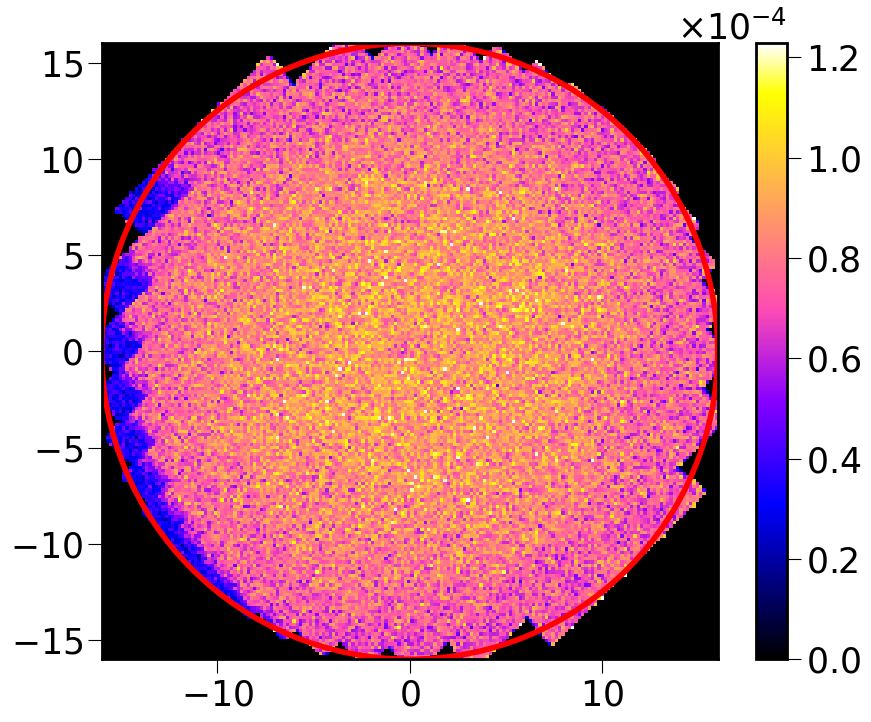

In [31]:
lt0 = lt.loc[1000]
img = lt0.prob.values
plt.imshow( img.reshape(nbins, nbins)
          , origin = "lower"
          , vmin   = 0
          , vmax   = np.percentile(img, 99.9)
          , extent = (-rmax, rmax, -rmax, rmax))

draw_el(plt.gca(), 16)
plt.colorbar()